# Current-to-temperature calibration

This notebook calibrates the warmth sensor's two current channels (`Primary` and `Secondary`) against `Sensor_T0_C`. For every valid, matched run, the **first** `Sensor_T0_C` value is paired with the **first** current reading in its preprocessed file, as specified.

The fitted equations predict temperature in °C from current in A. Because `Sensor_T0_C` occupies a narrow ambient-temperature range, the resulting model is an **initial-temperature calibration**; extrapolation beyond the observed range should be validated with additional reference-temperature measurements.

In [1]:
from pathlib import Path
import json
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import LeaveOneOut, cross_val_predict

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 30)

def find_project_root(start=Path.cwd()):
    for candidate in [start, *start.parents]:
        if (candidate / 'data' / '00_metadata').is_dir():
            return candidate
    raise FileNotFoundError('Could not locate the project root containing data/00_metadata')

ROOT = find_project_root()
RESULTS_DIR = ROOT / 'results' / 'temperature_calibration'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
ROOT

PosixPath('/Users/markkeanujamesexconde/Library/CloudStorage/OneDrive-Personal/Documents/Academe Files/4. Doctoral/Research 1 - Warmth Sensor/Warmth-Sensor-Object-Detection')

## Dataset mapping

Folder labels identify the acquisition condition. Calibration targets come from each matched metadata row's `Sensor_T0_C`, not from the folder label.

In [2]:
DATASETS = {
    '30C': '2026-07-27',
    '40C': '2026-07-07',
    '50C': '2026-07-25',
    '60C': '2026-07-26',
}

MATERIAL_ALIASES = {
    'al': 'aluminum', 'aluminum': 'aluminum',
    'bi': 'bismuth', 'bismuth': 'bismuth',
    'cu': 'copper', 'copper': 'copper',
    'fe': 'iron', 'iron': 'iron',
    'ni': 'nickel', 'nickel': 'nickel',
    'ti': 'titanium', 'titanium': 'titanium',
    'carbon': 'graphite', 'graphite': 'graphite',
    'ps': 'ps_foam', 'ps_foam': 'ps_foam',
    'pu': 'pu_foam', 'pu_foam': 'pu_foam',
    'cork': 'cork_fine', 'cork_fine': 'cork_fine',
}

def normalize_material(value):
    key = re.sub(r'[^a-z0-9]+', '_', str(value).strip().lower()).strip('_')
    return MATERIAL_ALIASES.get(key, key)

def is_valid(series):
    return series.astype(str).str.strip().str.lower().isin({'true', '1', 'yes', 'y'})

DATASETS

{'30C': '2026-07-27',
 '40C': '2026-07-07',
 '50C': '2026-07-25',
 '60C': '2026-07-26'}

## Match metadata to preprocessed files

Files are matched on normalized material name and trial number. Invalid metadata rows are excluded. Duplicate valid keys cause an explicit error instead of silently selecting a row.

In [3]:
records, audit = [], []

for condition, date in DATASETS.items():
    metadata_path = ROOT / 'data' / '00_metadata' / f'{date}.csv'
    data_dir = ROOT / 'data' / '02_preprocessed' / condition
    metadata = pd.read_csv(metadata_path)
    metadata = metadata.loc[is_valid(metadata['Valid'])].copy()
    metadata['material_key'] = metadata['Material'].map(normalize_material)
    metadata['trial_key'] = pd.to_numeric(metadata['Trial'], errors='coerce').astype('Int64')

    duplicate_keys = metadata.duplicated(['material_key', 'trial_key'], keep=False)
    if duplicate_keys.any():
        duplicates = metadata.loc[duplicate_keys, ['Material', 'Trial', 'Run_no']]
        raise ValueError(f'Duplicate valid metadata keys in {metadata_path}:\n{duplicates}')

    lookup = metadata.set_index(['material_key', 'trial_key'])
    matched = 0
    for file_path in sorted(data_dir.glob('*.csv')):
        frame = pd.read_csv(file_path)
        if frame.empty:
            continue
        first = frame.iloc[0]
        material = normalize_material(first['Sample'])
        trial = int(first['Trial'])
        key = (material, trial)
        if key not in lookup.index:
            continue
        meta = lookup.loc[key]
        records.append({
            'condition': condition, 'date': date, 'file': file_path.name,
            'material': material, 'trial': trial,
            'sensor_t0_c': float(meta['Sensor_T0_C']),
            'primary_a': float(first['Primary']),
            'secondary_a': float(first['Secondary']),
        })
        matched += 1
    audit.append({'condition': condition, 'date': date, 'valid_metadata_rows': len(metadata),
                  'preprocessed_files': len(list(data_dir.glob('*.csv'))), 'matched_pairs': matched})

calibration = pd.DataFrame(records).sort_values(['condition', 'material', 'trial']).reset_index(drop=True)
audit = pd.DataFrame(audit)
display(audit)
display(calibration.head())
print(f'Calibration pairs: {len(calibration):,}')
print(f'Observed Sensor_T0_C range: {calibration.sensor_t0_c.min():.2f}–{calibration.sensor_t0_c.max():.2f} °C')

,condition,date,valid_metadata_rows,preprocessed_files,matched_pairs
0,30C,2026-07-27,84,84,84
1,40C,2026-07-07,45,84,45
2,50C,2026-07-25,84,84,84
3,60C,2026-07-26,84,84,84


,condition,date,file,material,trial,sensor_t0_c,primary_a,secondary_a
0,30C,2026-07-27,al_1.csv,aluminum,1,25.4,0.000659,0.000700
1,30C,2026-07-27,al_2.csv,aluminum,2,25.4,0.000660,0.000700
2,30C,2026-07-27,al_3.csv,aluminum,3,25.2,0.000660,0.000700
3,30C,2026-07-27,al_4.csv,aluminum,4,25.3,0.000660,0.000699
4,30C,2026-07-27,al_5.csv,aluminum,5,25.1,0.000659,0.000700


Calibration pairs: 297
Observed Sensor_T0_C range: 24.80–27.00 °C


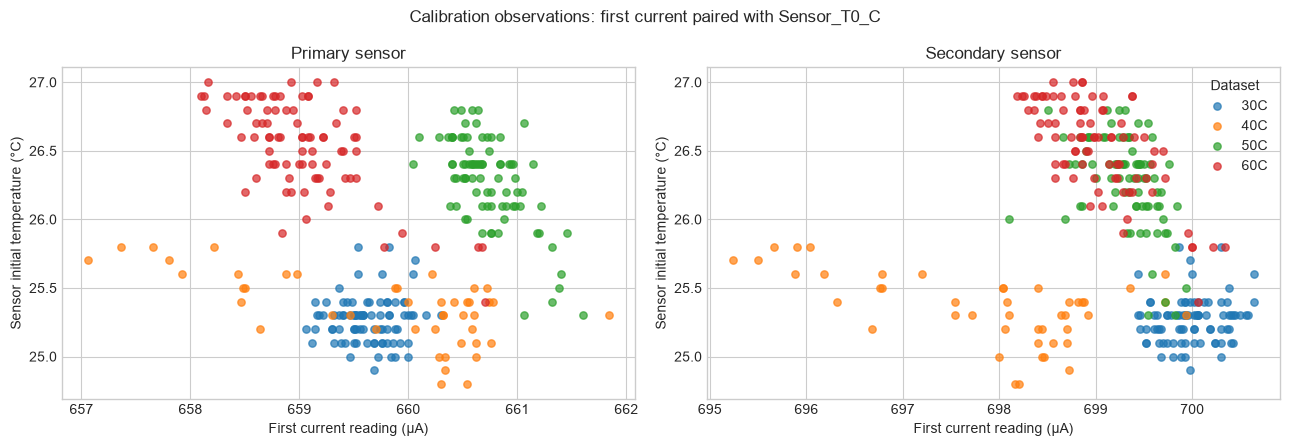

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, column, title in zip(axes, ['primary_a', 'secondary_a'], ['Primary sensor', 'Secondary sensor']):
    for condition, group in calibration.groupby('condition', sort=True):
        ax.scatter(group[column] * 1e6, group['sensor_t0_c'], s=28, alpha=0.7, label=condition)
    ax.set(title=title, xlabel='First current reading (µA)', ylabel='Sensor initial temperature (°C)')
axes[1].legend(title='Dataset')
fig.suptitle('Calibration observations: first current paired with Sensor_T0_C')
fig.tight_layout()
plt.show()

## Fit one calibration per sensor

An ordinary least-squares line is used for an interpretable relationship, `temperature = slope × current + intercept`. Leave-one-out cross-validation (LOOCV) reports prediction error without evaluating each observation on the same fit that trained on it.

In [5]:
models, metric_rows = {}, []
y = calibration['sensor_t0_c'].to_numpy()

for sensor, current_column in {'Primary': 'primary_a', 'Secondary': 'secondary_a'}.items():
    X = calibration[[current_column]].to_numpy()
    model = LinearRegression().fit(X, y)
    fitted = model.predict(X)
    cv_prediction = cross_val_predict(LinearRegression(), X, y, cv=LeaveOneOut())
    models[sensor] = model
    calibration[f'{sensor.lower()}_fitted_c'] = fitted
    calibration[f'{sensor.lower()}_loocv_c'] = cv_prediction
    metric_rows.append({
        'sensor': sensor, 'current_column': current_column,
        'slope_c_per_a': model.coef_[0], 'intercept_c': model.intercept_,
        'r2_in_sample': r2_score(y, fitted),
        'mae_c_loocv': mean_absolute_error(y, cv_prediction),
        'rmse_c_loocv': mean_squared_error(y, cv_prediction) ** 0.5,
        'calibration_min_c': y.min(), 'calibration_max_c': y.max(),
    })

metrics = pd.DataFrame(metric_rows).set_index('sensor')
display(metrics.round({
    'slope_c_per_a': 6, 'intercept_c': 4, 'r2_in_sample': 4,
    'mae_c_loocv': 4, 'rmse_c_loocv': 4,
    'calibration_min_c': 2, 'calibration_max_c': 2,
}))
for sensor, row in metrics.iterrows():
    print(f"{sensor}: T (°C) = {row.slope_c_per_a:.8g} × I (A) + {row.intercept_c:.6g}")

,current_column,slope_c_per_a,intercept_c,r2_in_sample,mae_c_loocv,rmse_c_loocv,calibration_min_c,calibration_max_c
sensor,,,,,,,,
Primary,primary_a,-109928.590309,98.4531,0.0226,0.5757,0.6224,24.8,27.0
Secondary,secondary_a,-151716.528787,132.0041,0.0470,0.5597,0.6158,24.8,27.0


Primary: T (°C) = -109928.59 × I (A) + 98.4531
Secondary: T (°C) = -151716.53 × I (A) + 132.004


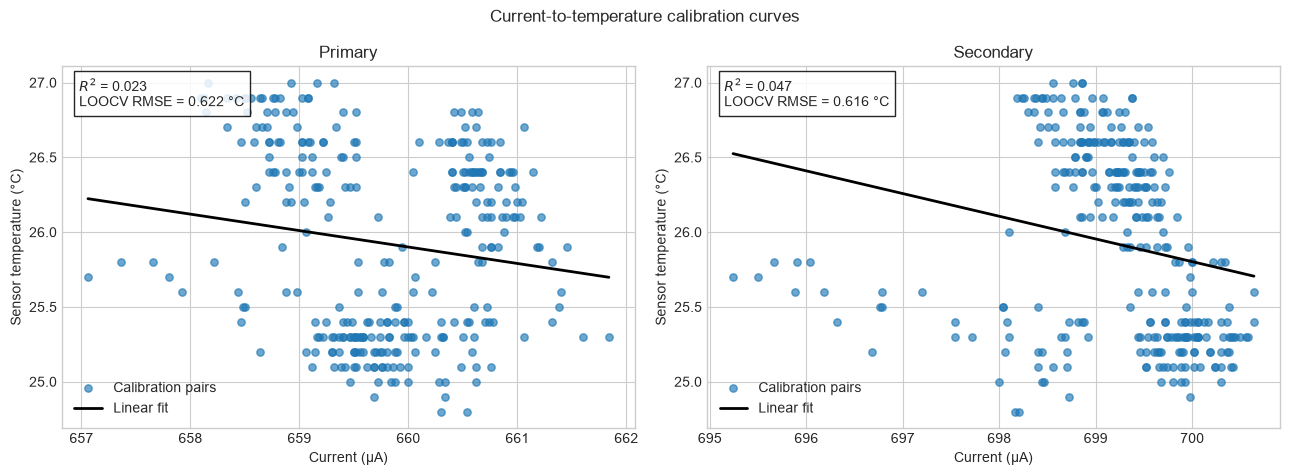

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for ax, (sensor, current_column) in zip(axes, {'Primary': 'primary_a', 'Secondary': 'secondary_a'}.items()):
    x = calibration[current_column].to_numpy()
    order = np.argsort(x)
    ax.scatter(x * 1e6, y, s=28, alpha=0.65, label='Calibration pairs')
    ax.plot(x[order] * 1e6, models[sensor].predict(x[order, None]), color='black', lw=2, label='Linear fit')
    row = metrics.loc[sensor]
    ax.text(0.03, 0.97, f"$R^2$ = {row.r2_in_sample:.3f}\nLOOCV RMSE = {row.rmse_c_loocv:.3f} °C",
            transform=ax.transAxes, va='top', bbox={'facecolor': 'white', 'alpha': 0.85})
    ax.set(title=sensor, xlabel='Current (µA)', ylabel='Sensor temperature (°C)')
    ax.legend()
fig.suptitle('Current-to-temperature calibration curves')
fig.tight_layout()
plt.show()

## Residual checks

Residuals should be centered around zero without curvature or dataset-specific separation. Strong structure here indicates that a single linear calibration is insufficient.

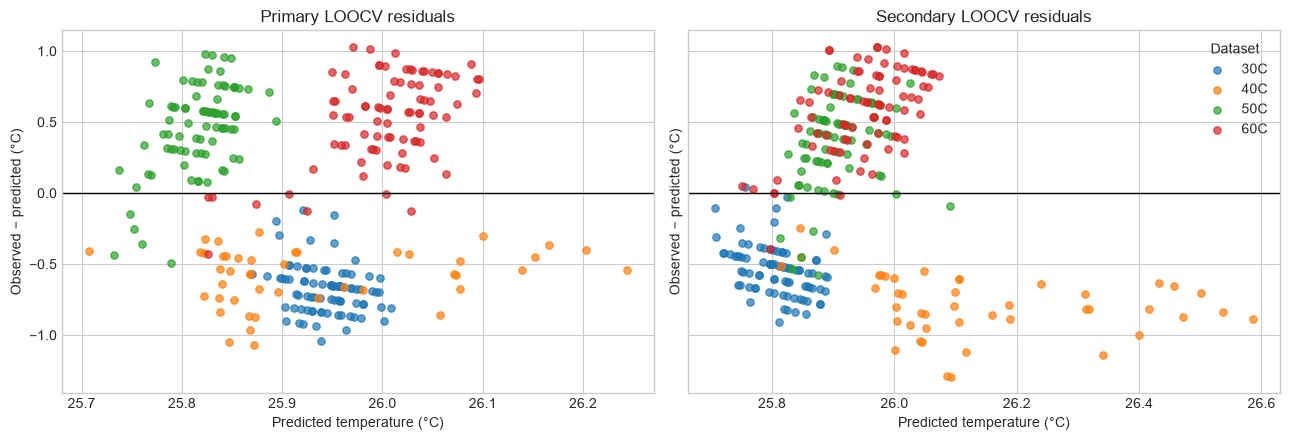

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, sensor in zip(axes, ['Primary', 'Secondary']):
    predicted = calibration[f'{sensor.lower()}_loocv_c']
    residual = calibration['sensor_t0_c'] - predicted
    for condition, idx in calibration.groupby('condition').groups.items():
        ax.scatter(predicted.loc[idx], residual.loc[idx], s=28, alpha=0.7, label=condition)
    ax.axhline(0, color='black', lw=1)
    ax.set(title=f'{sensor} LOOCV residuals', xlabel='Predicted temperature (°C)', ylabel='Observed − predicted (°C)')
axes[1].legend(title='Dataset')
fig.tight_layout()
plt.show()

## Conversion helpers and export

These functions convert any current array using the fitted calibration. The warning highlights extrapolation outside the observed `Sensor_T0_C` range.

In [8]:
def current_to_temperature(current_a, sensor='Primary'):
    """Convert current in amperes to degrees Celsius."""
    if sensor not in models:
        raise ValueError(f"sensor must be one of {list(models)}")
    values = np.asarray(current_a, dtype=float)
    return models[sensor].predict(values.reshape(-1, 1)).reshape(values.shape)

def add_temperature_columns(frame):
    result = frame.copy()
    result['Primary_T_C'] = current_to_temperature(result['Primary'], 'Primary')
    result['Secondary_T_C'] = current_to_temperature(result['Secondary'], 'Secondary')
    return result

parameters = {
    sensor: {
        'input_unit': 'A', 'output_unit': 'degC',
        'slope_c_per_a': float(model.coef_[0]), 'intercept_c': float(model.intercept_),
        'calibration_temperature_range_c': [float(y.min()), float(y.max())],
        'pairing_rule': 'Sensor_T0_C paired with first current sample of matched valid run',
    } for sensor, model in models.items()
}

calibration.to_csv(RESULTS_DIR / 'calibration_pairs_and_predictions.csv', index=False)
metrics.reset_index().to_csv(RESULTS_DIR / 'calibration_metrics.csv', index=False)
with open(RESULTS_DIR / 'current_to_temperature_parameters.json', 'w') as handle:
    json.dump(parameters, handle, indent=2)

example_path = ROOT / 'data' / '02_preprocessed' / '30C' / 'al_1.csv'
example = add_temperature_columns(pd.read_csv(example_path))
display(example[['Time', 'Primary', 'Primary_T_C', 'Secondary', 'Secondary_T_C']].head())
print(f'Calibration artifacts written to: {RESULTS_DIR}')

,Time,Primary,Primary_T_C,Secondary,Secondary_T_C
0,0.00941,0.000659,25.994800,0.0007,25.778248
1,0.10066,0.000660,25.942035,0.0007,25.805557
2,0.20066,0.000660,25.942035,0.0007,25.802522
3,0.30066,0.000660,25.944233,0.0007,25.811625
4,0.40070,0.000660,25.944233,0.0007,25.817694


Calibration artifacts written to: /Users/markkeanujamesexconde/Library/CloudStorage/OneDrive-Personal/Documents/Academe Files/4. Doctoral/Research 1 - Warmth Sensor/Warmth-Sensor-Object-Detection/results/temperature_calibration


## Interpretation note

The nominal `30C`–`60C` folder names are acquisition conditions, but the supplied calibration target (`Sensor_T0_C`) is the sensor's initial temperature and is near room temperature. Consequently, this notebook does not claim that later current readings represent the folder temperature. To calibrate reliably across 30–60 °C, collect synchronized reference sensor temperatures throughout each current trace (or at stable endpoints) and fit against those measured temperatures.

In [20]:
calibration.head(75)

,condition,date,file,material,trial,sensor_t0_c,primary_a,secondary_a,primary_fitted_c,primary_loocv_c,secondary_fitted_c,secondary_loocv_c
0,30C,2026-07-27,al_1.csv,aluminum,1,25.4,0.000659,0.000700,25.994800,25.997960,25.778248,25.781011
1,30C,2026-07-27,al_2.csv,aluminum,2,25.4,0.000660,0.000700,25.928843,25.930635,25.869278,25.871121
2,30C,2026-07-27,al_3.csv,aluminum,3,25.2,0.000660,0.000700,25.953028,25.955817,25.854106,25.856904
3,30C,2026-07-27,al_4.csv,aluminum,4,25.3,0.000660,0.000699,25.948630,25.950974,25.887484,25.889612
4,30C,2026-07-27,al_5.csv,aluminum,5,25.1,0.000659,0.000700,25.975013,25.978848,25.814660,25.818650
...,...,...,...,...,...,...,...,...,...,...,...,...
70,30C,2026-07-27,pu_5.csv,pu_foam,5,25.5,0.000659,0.000700,25.970616,25.972601,25.744870,25.747153
71,30C,2026-07-27,pu_6.csv,pu_foam,6,25.2,0.000660,0.000700,25.955226,25.958062,25.757007,25.761765
72,30C,2026-07-27,ti_1.csv,titanium,1,25.1,0.000660,0.000700,25.900262,25.903137,25.841969,25.845395
73,30C,2026-07-27,ti_2.csv,titanium,2,25.1,0.000659,0.000700,25.964020,25.967474,25.766110,25.771433
